In [1]:
# Imports
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LogisticRegression

In [2]:
# Load the data
test = pd.read_csv('data/test.csv', index_col="id") 
train = pd.read_csv('data/train.csv', index_col="id")

# Combine both for plotting
df = pd.concat([train, test], sort=False)

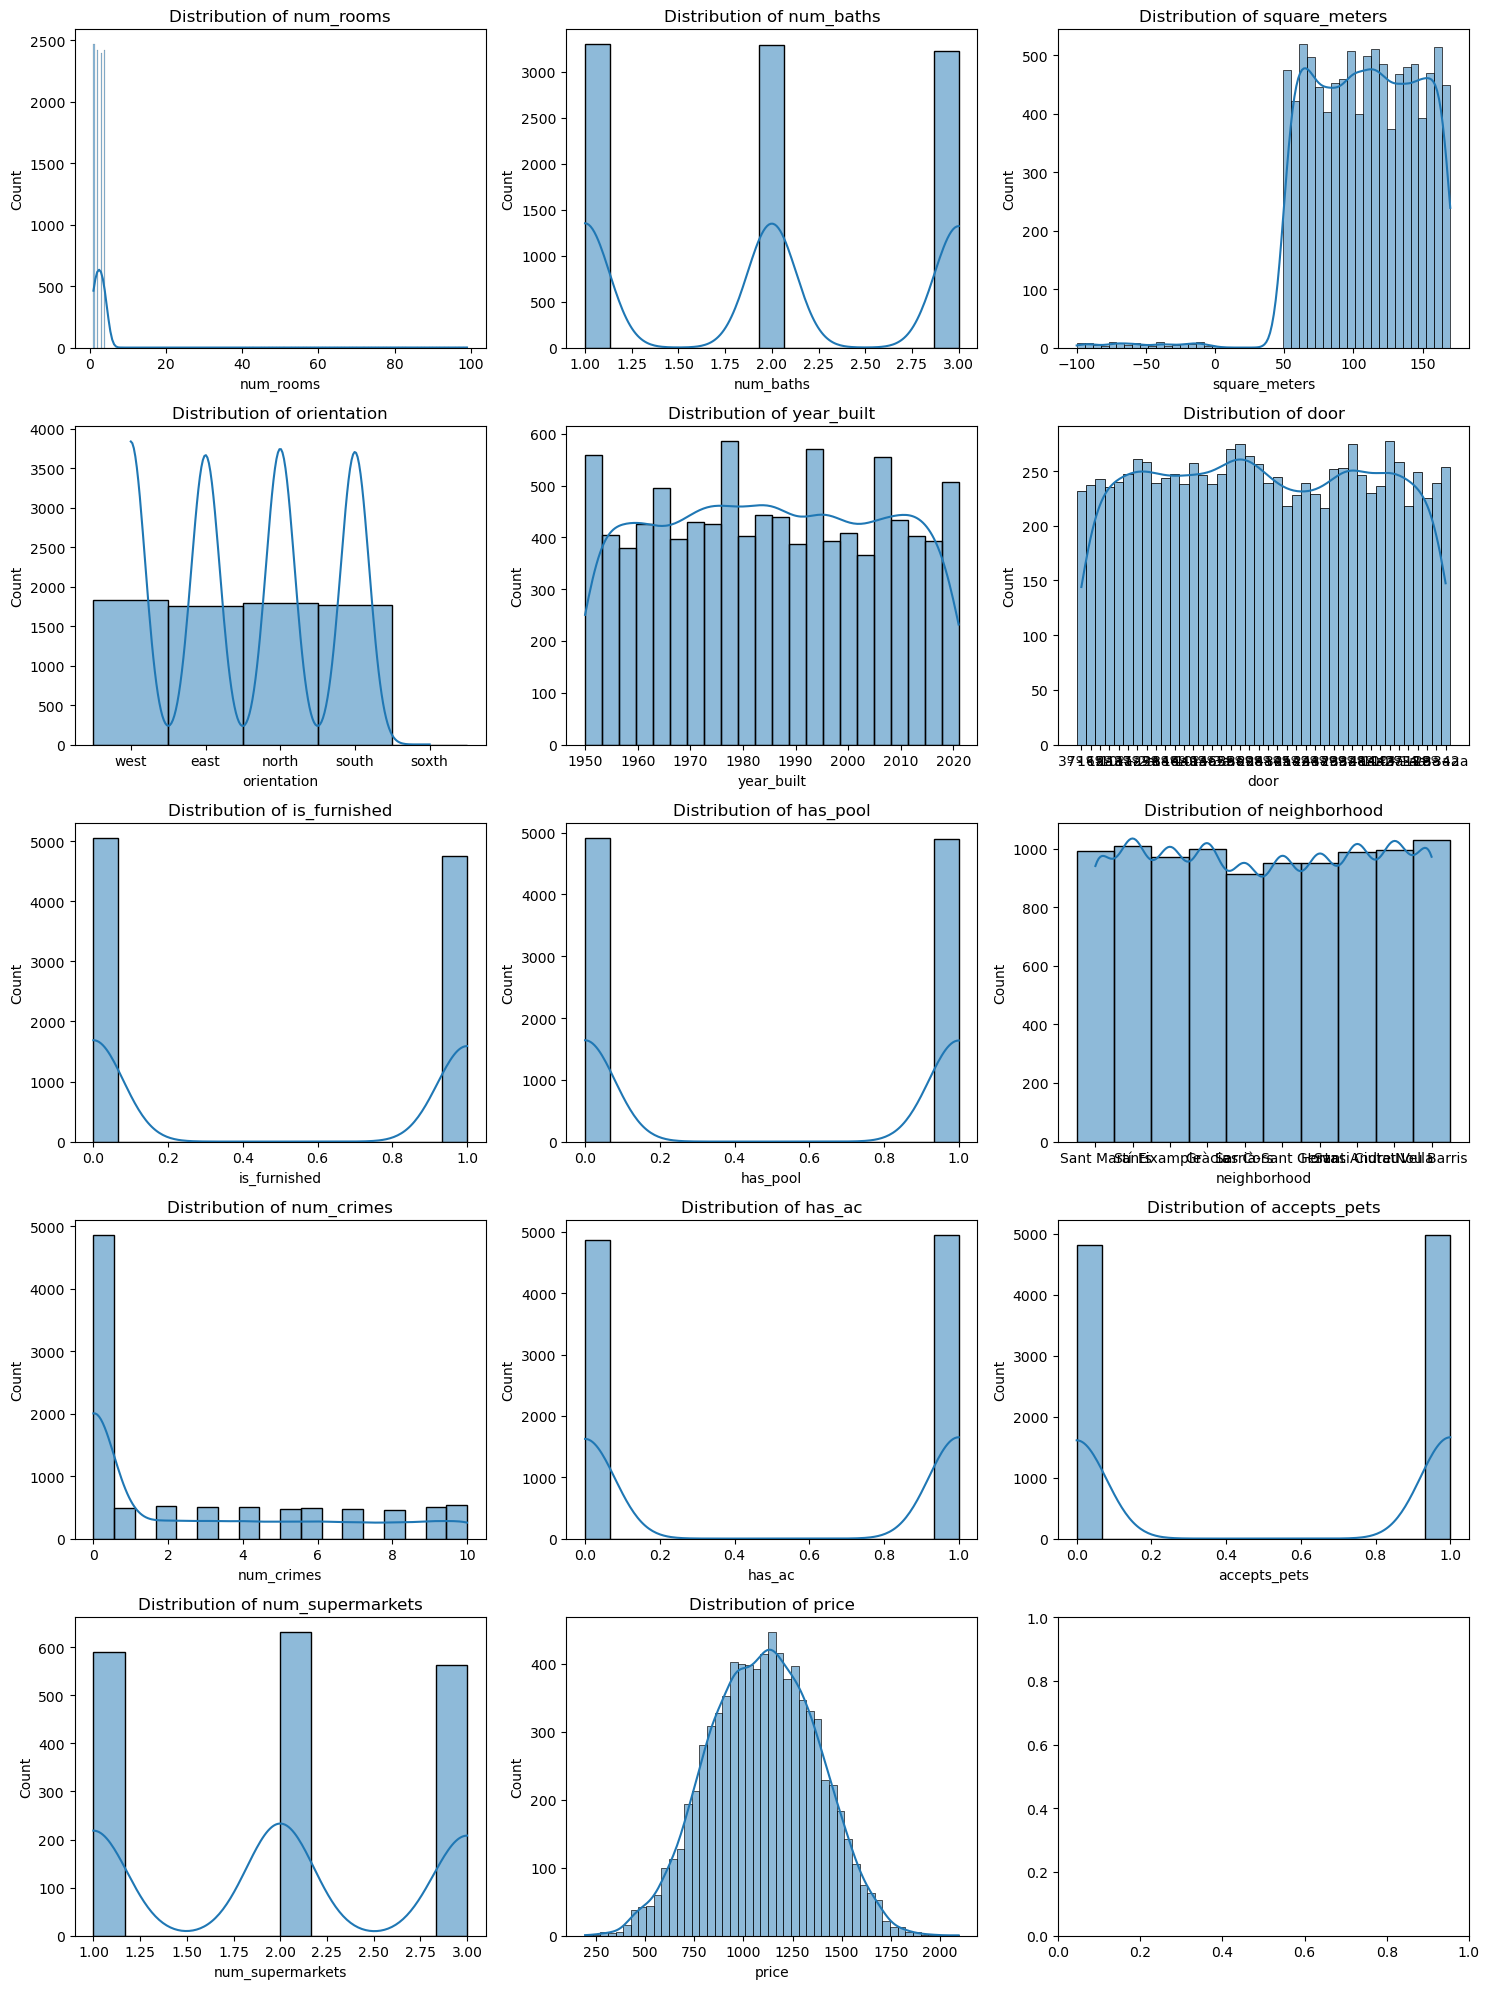

In [3]:
# Plot all variables

# Set up the matplotlib figure
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(15, 20))
axes = axes.flatten()

# Plot the distribution of each column
for i, col in enumerate(df.columns):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

# Adjust layout
plt.tight_layout()
plt.show()

In [4]:
# Check for missing values
print(df.isnull().sum())

num_rooms            191
num_baths            200
square_meters        198
orientation         2864
year_built           200
door                 200
is_furnished         200
has_pool             200
neighborhood         200
num_crimes           200
has_ac               200
accepts_pets         200
num_supermarkets    8215
price               2000
dtype: int64


In [5]:
# Unique values per column
for col in df.columns:
    print(f'{col}: {df[col].nunique()}')

num_rooms: 56
num_baths: 3
square_meters: 187
orientation: 5
year_built: 72
door: 40
is_furnished: 2
has_pool: 2
neighborhood: 10
num_crimes: 11
has_ac: 2
accepts_pets: 2
num_supermarkets: 3
price: 1279


In [6]:
# Encode string columns with numbers
df1 = df.copy()
for col in df1.columns:
    if df1[col].dtype == 'object':
        df1[col]= pd.factorize(df1[col])[0]
        df1[col] = df1[col].apply(lambda x: None if x < 0 else x)

<Axes: >

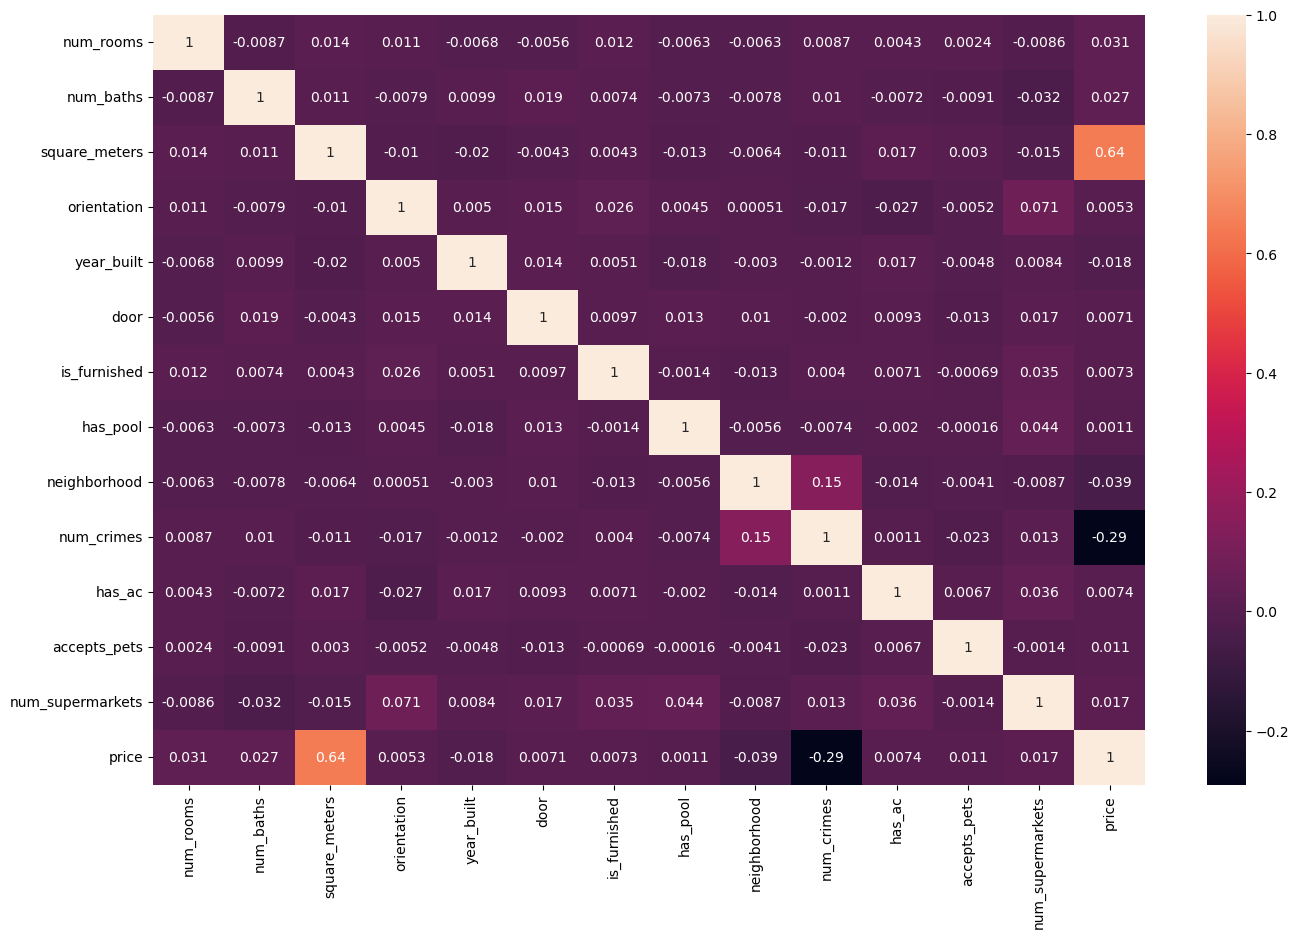

In [7]:
# Correlation matrix of numeric values
plt.figure(figsize=(16, 10))
sns.heatmap(df1.corr(numeric_only=True), annot=True)

In [8]:
# Booleans first
df1_1 = df1.copy()
# OR Probabilistic imputation based on observed distribution
def prob_impute(series):
    prob_true = series.dropna().mean()  # proportion of True values
    print(prob_true)
    n_missing = series.isna().sum()
    # Generate random boolean values with same probability as observed
    return series.fillna(pd.Series(
        np.random.choice(
            [True, False], 
            size=n_missing, 
            p=[prob_true, 1-prob_true]
        )
    ))

# Apply to boolean columns
for col in df1.columns:
    if any(bool_col in col for bool_col in ["has_", "accepts_", "is_"]):
        print(f'Imputing {col}')
        df1[col] = prob_impute(df1[col])
        s = prob_impute(df1[col])

Imputing is_furnished
0.4851020408163265
0.48520710059171596
Imputing has_pool
0.4993877551020408
0.4992858600285656
Imputing has_ac
0.4959183673469388
0.496124821537834
Imputing accepts_pets
0.4923469387755102
0.4924520603835169


In [9]:
# String columns next
df1.isnull().sum()

num_rooms            191
num_baths            200
square_meters        198
orientation         2864
year_built           200
door                 200
is_furnished         198
has_pool             198
neighborhood         200
num_crimes           200
has_ac               194
accepts_pets         196
num_supermarkets    8215
price               2000
dtype: int64

In [21]:
import numpy as np
import pandas as pd
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from scipy import stats

def generate_sample_data(n_samples=1000, missing_ratio=0.2, outlier_ratio=0.1):
    """
    Generate sample data with missing values and outliers
    """
    # Generate base random normal data
    np.random.seed(42)
    X = np.random.normal(loc=10, scale=2, size=n_samples)
    
    # Add some noise
    noise = np.random.normal(0, 0.5, n_samples)
    X = X + noise
    
    # Introduce outliers
    n_outliers = int(n_samples * outlier_ratio)
    outlier_idx = np.random.choice(n_samples, n_outliers, replace=False)
    X[outlier_idx] = X[outlier_idx] * np.random.uniform(3, 5, n_outliers)
    
    # Introduce missing values
    n_missing = int(n_samples * missing_ratio)
    missing_idx = np.random.choice(n_samples, n_missing, replace=False)
    X[missing_idx] = np.nan
    
    return X

def compare_imputation_methods(data):
    """
    Compare different imputation methods
    """
    # Create copies for different methods
    data_mean = data.copy()
    data_median = data.copy()
    data_knn = data.copy()
    data_robust = data.copy()
    
    # 1. Mean imputation
    mean_imputer = SimpleImputer(strategy='mean')
    data_mean = mean_imputer.fit_transform(data.reshape(-1, 1)).ravel()
    
    # 2. Median imputation
    median_imputer = SimpleImputer(strategy='median')
    data_median = median_imputer.fit_transform(data.reshape(-1, 1)).ravel()
    
    # 3. KNN imputation
    knn_imputer = KNNImputer(n_neighbors=5)
    data_knn = knn_imputer.fit_transform(data.reshape(-1, 1)).ravel()
    
    # 4. Robust imputation (handling outliers first)
    def robust_impute(data):
        # First detect outliers
        data_for_iforest = data.reshape(-1, 1)
        mask = ~np.isnan(data)
        iforest = IsolationForest(contamination=0.1, random_state=42)
        outlier_labels = iforest.fit_predict(data_for_iforest[mask].reshape(-1, 1))
        
        # Create clean dataset without outliers for computing statistics
        clean_data = data[mask][outlier_labels == 1]
        
        # Calculate robust statistics
        robust_mean = np.mean(clean_data)
        robust_std = np.std(clean_data)
        
        # Replace outliers with winsorized values
        data_robust = np.copy(data)
        data_robust[mask][outlier_labels == -1] = np.clip(
            data_robust[mask][outlier_labels == -1],
            robust_mean - 2*robust_std,
            robust_mean + 2*robust_std
        )
        
        # Impute remaining missing values using KNN
        knn_imputer = KNNImputer(n_neighbors=5)
        data_robust = knn_imputer.fit_transform(data_robust.reshape(-1, 1)).ravel()
        
        return data_robust
    
    data_robust = robust_impute(data)
    
    # Evaluate methods
    missing_mask = np.isnan(data)
    original_complete = data[~missing_mask]
    
    results = {
        'Mean Imputation': data_mean,
        'Median Imputation': data_median,
        'KNN Imputation': data_knn,
        'Robust Imputation': data_robust
    }
    
    # Calculate statistics
    stats_results = {}
    for method, imputed_data in results.items():
        stats_results[method] = {
            'Mean': np.mean(imputed_data),
            'Median': np.median(imputed_data),
            'Std': np.std(imputed_data),
            'Skewness': stats.skew(imputed_data)
        }
    
    return results, stats_results

def plot_results(original_data, imputation_results):
    """
    Plot original data and imputation results
    """
    fig, axes = plt.subplots(3, 2, figsize=(15, 12))
    fig.suptitle('Comparison of Imputation Methods')
    
    # Original data with missing values
    axes[0, 0].hist(original_data[~np.isnan(original_data)], bins=30, alpha=0.7)
    axes[0, 0].set_title('Original Data (excluding missing values)')
    axes[0, 0].set_xlabel('Value')
    axes[0, 0].set_ylabel('Frequency')
    
    # Plot histograms for each method
    plot_positions = [(0, 1), (1, 0), (1, 1), (2, 0)]
    for (method, data), pos in zip(imputation_results.items(), plot_positions):
        axes[pos[0], pos[1]].hist(data, bins=30, alpha=0.7)
        axes[pos[0], pos[1]].set_title(f'{method}')
        axes[pos[0], pos[1]].set_xlabel('Value')
        axes[pos[0], pos[1]].set_ylabel('Frequency')
    
    # Add box plot comparison
    data_to_plot = [imputation_results[method] for method in imputation_results.keys()]
    axes[2, 1].boxplot(data_to_plot, labels=[m[:10] for m in imputation_results.keys()])
    axes[2, 1].set_title('Distribution Comparison')
    axes[2, 1].set_xticklabels([m[:10] for m in imputation_results.keys()], rotation=45)
    
    plt.tight_layout()
    return fig

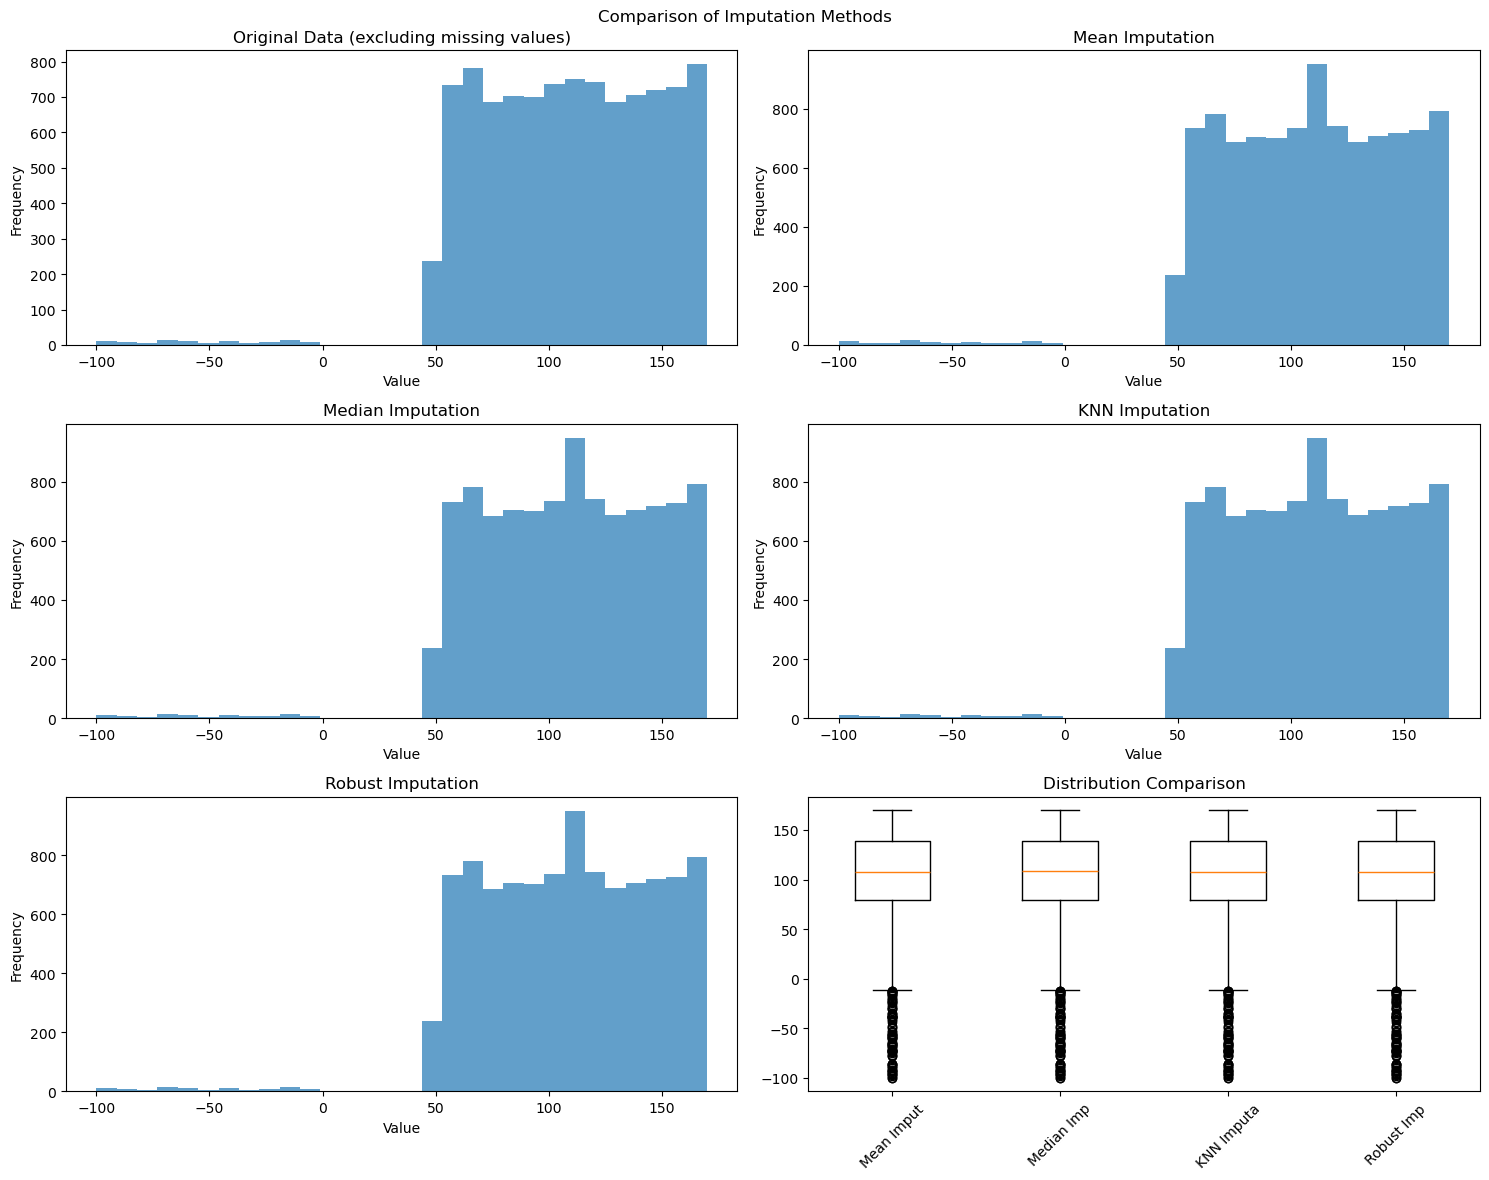

In [22]:
X = df["square_meters"].to_numpy()
results, stats_results = compare_imputation_methods(X)
fig = plot_results(X, results)

In [23]:
import numpy as np
import pandas as pd
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.experimental import enable_iterative_imputer
from sklearn.preprocessing import RobustScaler
from sklearn.covariance import EllipticEnvelope
import warnings
warnings.filterwarnings('ignore')

class MARobustImputer:
    """
    Robust imputation for MAR data with outliers using multiple steps:
    1. Initial outlier detection and treatment
    2. Multiple Imputation using MICE with robust estimators
    3. Post-imputation outlier validation
    """
    def __init__(self, 
                 n_imputations=5,
                 outlier_contamination=0.1,
                 max_iter=100,
                 random_state=42):
        self.n_imputations = n_imputations
        self.contamination = outlier_contamination
        self.max_iter = max_iter
        self.random_state = random_state
        
    def _detect_outliers(self, X):
        """
        Ensemble outlier detection using multiple methods
        """
        # Use both IsolationForest and Robust Covariance
        iforest = IsolationForest(contamination=self.contamination,
                                random_state=self.random_state)
        envelope = EllipticEnvelope(contamination=self.contamination,
                                  random_state=self.random_state)
        
        # For non-missing values, get outlier scores
        mask = ~np.isnan(X)
        X_valid = X[mask].reshape(-1, 1)
        
        if len(X_valid) > 0:
            # Combine predictions from both methods
            scores1 = iforest.fit_predict(X_valid)
            scores2 = envelope.fit_predict(X_valid)
            
            # Consider a point an outlier if both methods agree
            outlier_mask = (scores1 == -1) & (scores2 == -1)
            
            # Create full mask including missing values
            full_mask = np.zeros_like(X, dtype=bool)
            full_mask[mask] = outlier_mask
            
            return full_mask
        return np.zeros_like(X, dtype=bool)

    def _robust_mice_imputation(self, X):
        """
        Perform MICE imputation with robust random forests
        """
        # Initialize robust random forest
        rf = RandomForestRegressor(n_estimators=100,
                                 max_samples=0.8,  # Use bagging for robustness
                                 random_state=self.random_state)
        
        # Create MICE imputer with robust estimator
        mice = IterativeImputer(estimator=rf,
                              n_nearest_features=None,  # Use all features
                              initial_strategy='median',  # Start with robust initial values
                              max_iter=self.max_iter,
                              random_state=self.random_state)
        
        return mice.fit_transform(X.reshape(-1, 1))

    def _validate_imputed_values(self, X_orig, X_imputed):
        """
        Validate and adjust imputed values to maintain distribution characteristics
        """
        # Get statistics from non-missing original data
        valid_mask = ~np.isnan(X_orig)
        if np.sum(valid_mask) > 0:
            orig_median = np.median(X_orig[valid_mask])
            orig_iqr = np.percentile(X_orig[valid_mask], 75) - \
                      np.percentile(X_orig[valid_mask], 25)
            
            # Identify imputed values
            imputed_mask = np.isnan(X_orig)
            
            # Adjust extreme imputed values
            lower_bound = orig_median - 3 * orig_iqr
            upper_bound = orig_median + 3 * orig_iqr
            
            X_imputed[imputed_mask] = np.clip(X_imputed[imputed_mask],
                                            lower_bound,
                                            upper_bound)
        
        return X_imputed

    def fit_transform(self, X):
        """
        Main method to perform robust MAR imputation
        """
        X = np.array(X)
        
        # Step 1: Initial outlier detection
        outlier_mask = self._detect_outliers(X)
        
        # Step 2: Treat detected outliers as missing for imputation
        X_for_imputation = X.copy()
        X_for_imputation[outlier_mask] = np.nan
        
        # Step 3: Perform multiple imputations
        imputations = []
        for _ in range(self.n_imputations):
            # Perform MICE imputation
            X_imputed = self._robust_mice_imputation(X_for_imputation)
            # Validate and adjust imputed values
            X_imputed = self._validate_imputed_values(X, X_imputed)
            imputations.append(X_imputed)
        
        # Step 4: Combine multiple imputations
        X_final = np.mean(imputations, axis=0)
        
        # Step 5: Final validation
        X_final = self._validate_imputed_values(X, X_final)
        
        return X_final

In [24]:
mar = MARobustImputer()
fin = mar.fit_transform(X)

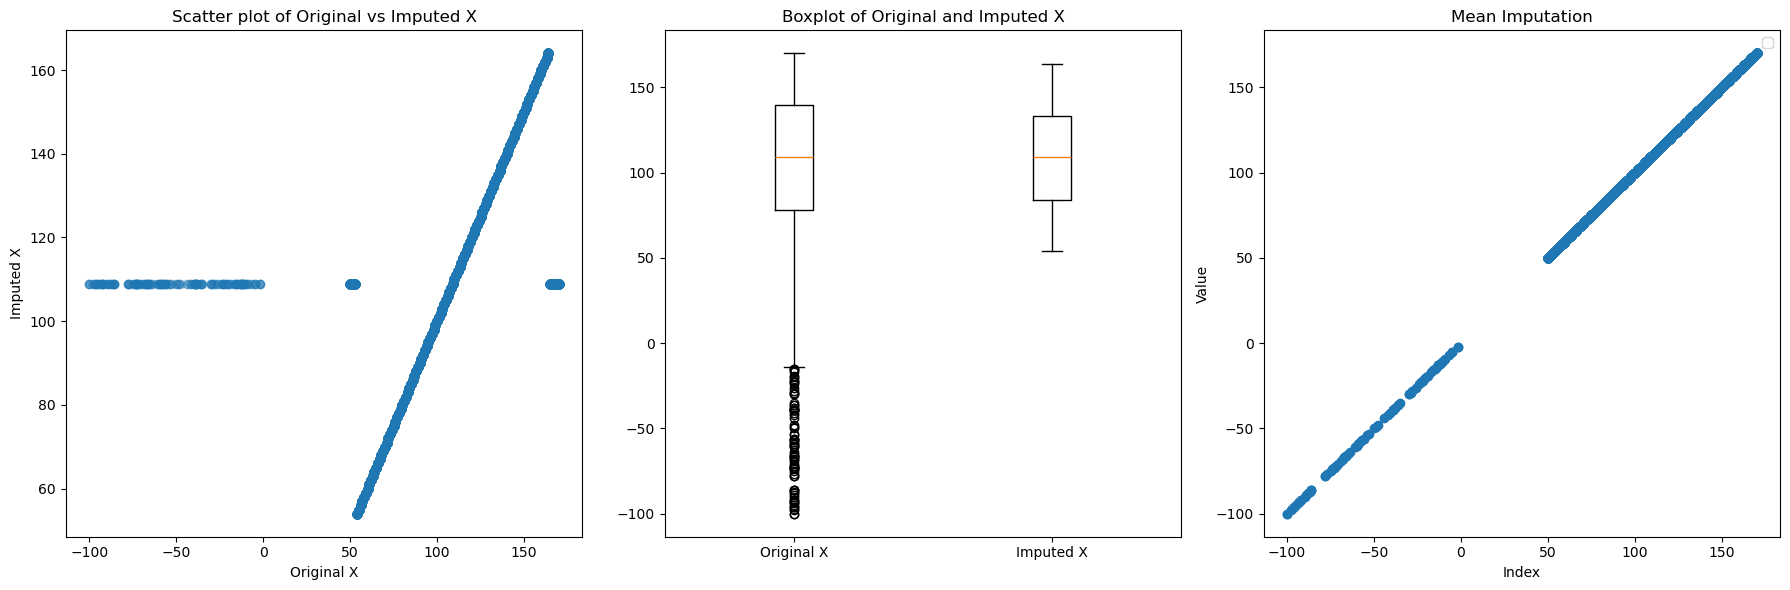

In [28]:
# Plot X vs fin
plt.figure(figsize=(18, 6))

# Scatter plot
plt.subplot(1, 3, 1)
plt.scatter(X, fin, alpha=0.5)
plt.xlabel('Original X')
plt.ylabel('Imputed X')
plt.title('Scatter plot of Original vs Imputed X')

# Boxplot
plt.subplot(1, 3, 2)
plt.boxplot([X[~np.isnan(X)], fin.ravel()], labels=['Original X', 'Imputed X'])
plt.title('Boxplot of Original and Imputed X')

# Plot mean column from results
plt.subplot(1, 3, 3)
plt.scatter(X, results["Mean Imputation"])
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Mean Imputation')
plt.legend()

plt.tight_layout()
plt.show()